# Data Preprocessing

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
data = pd.read_csv(r"C:\Users\Harsh Deep Yadav\Desktop\MachineLearning Projects\Regression Projects\RealEstatePricePredictor\Data\Housing.csv")
data.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Observing the values and the dataset and looking for NULL values and the different datatypes

In [6]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mea

In [7]:
print(data.isnull().sum())
print(data.dtypes)


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


Changing the categorical data into binary so the model can understand : 0 -> No, 1 -> Yes
Rounding the data to the 2nd decimal to get approximation of the price

In [8]:
data["mainroad"] = data["mainroad"].map({"yes": 1, "no": 0})
data["guestroom"] = data["guestroom"].map({"yes": 1, "no": 0})
data["basement"] = data["basement"].map({"yes": 1, "no": 0})
data["hotwaterheating"] = data["hotwaterheating"].map({"yes": 1, "no": 0})
data["airconditioning"] = data["airconditioning"].map({"yes": 1, "no": 0})
data["prefarea"] = data["prefarea"].map({"yes": 1, "no": 0})
data["furnishingstatus"] = data["furnishingstatus"].map({"furnished": 1, "semi-furnished": 0.5, "unfurnished": 0})

In [9]:
data["price"] = data["price"] / 1000000
data["price"] = data["price"].round(2)

In [10]:
print(data.head(3))

print(data.isna().sum())

print(data.info())

   price  area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  13.30  7420         4          2        3         1          0         0   
1  12.25  8960         4          4        4         1          0         0   
2  12.25  9960         3          2        2         1          0         1   

   hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  
0                0                1        2         1               1.0  
1                0                1        3         0               1.0  
2                0                0        2         1               0.5  
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns

# Outlier Removal using IQR (Interquartile Range)

In [11]:
Q1 = data["price"].quantile(0.25)
Q3 = data["price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

data = data[
    (data["price"] >= lower_limit) &
    (data["price"] <= upper_limit)
]

# Plotting of Features vs Features

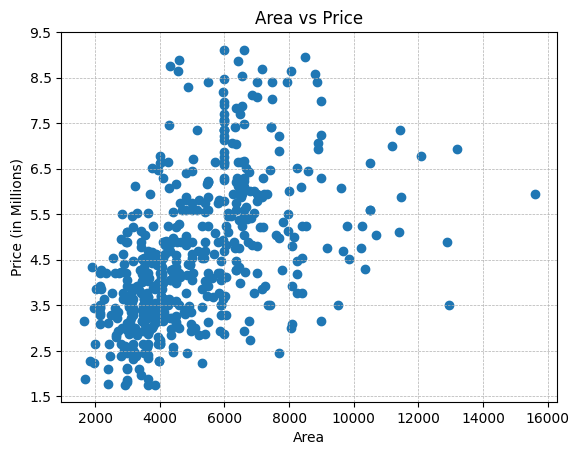

In [12]:
plt.scatter(data["area"], data["price"])
plt.xlabel("Area")
plt.ylabel("Price (in Millions)")
plt.title("Area vs Price")
plt.yticks(np.arange(1.5, 10.5, 1))
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,1.000000,0.509760,0.332256,0.458065,0.432489,0.310559,0.290139,0.195742,0.082855,0.462401,0.328396,0.292398,0.303267
area,0.509760,1.000000,0.112056,0.133472,0.063939,0.289321,0.155552,0.037246,0.002533,0.211505,0.344797,0.212723,0.170043
bedrooms,0.332256,0.112056,1.000000,0.350025,0.404628,-0.024639,0.076559,0.100002,0.029208,0.146859,0.110234,0.066364,0.110891
bathrooms,0.458065,0.133472,0.350025,1.000000,0.308026,0.023649,0.147393,0.120375,0.040149,0.174966,0.127184,0.032021,0.145684
stories,0.432489,0.063939,0.404628,0.308026,1.000000,0.116551,0.038356,-0.166370,0.020024,0.281968,0.019222,0.026019,0.100844
mainroad,0.310559,0.289321,-0.024639,0.023649,0.116551,1.000000,0.091658,0.041974,-0.017305,0.099208,0.197896,0.194901,0.153407
guestroom,0.290139,0.155552,0.076559,0.147393,0.038356,0.091658,1.000000,0.372114,-0.025219,0.135385,0.030815,0.170439,0.121165
basement,0.195742,0.037246,0.100002,0.120375,-0.166370,0.041974,0.372114,1.000000,0.000294,0.040937,0.031970,0.228963,0.104027
hotwaterheating,0.082855,0.002533,0.029208,0.040149,0.020024,-0.017305,-0.025219,0.000294,1.000000,-0.121215,0.051929,-0.047207,0.022760
airconditioning,0.462401,0.211505,0.146859,0.174966,0.281968,0.099208,0.135385,0.040937,-0.121215,1.000000,0.128370,0.087934,0.135633


Text(0.5, 1.0, 'Correlation Heatmap')

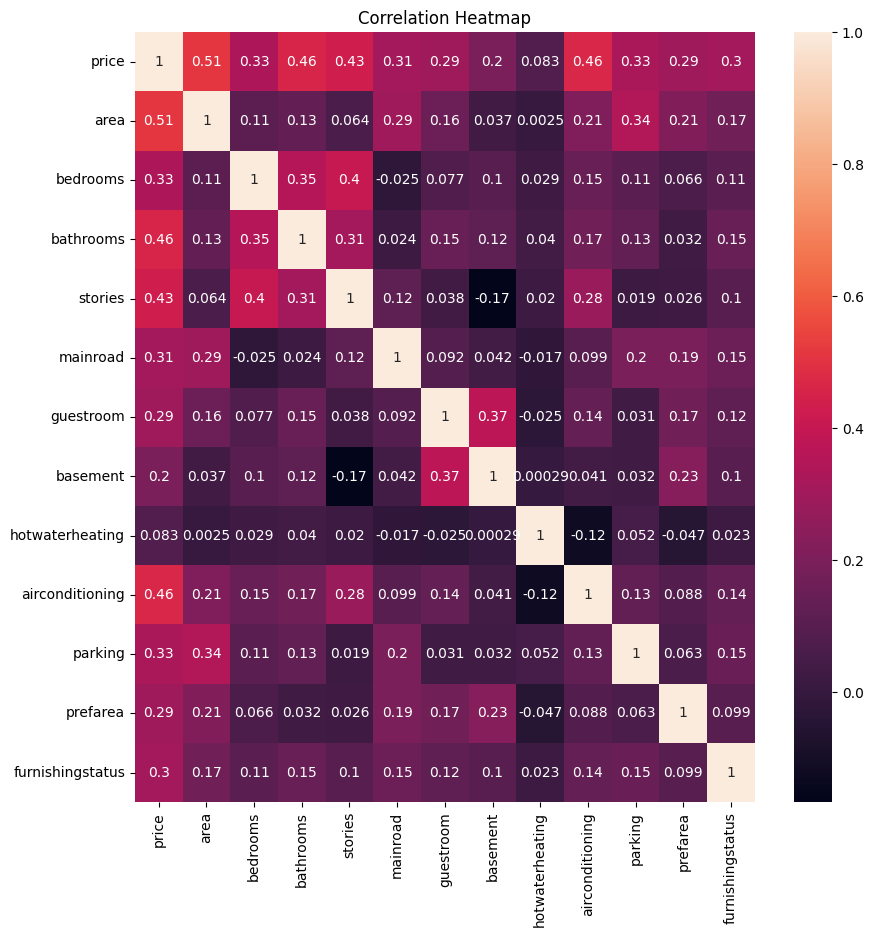

In [13]:
data_corr = data.corr()
display(data_corr)

plt.figure(figsize=(10, 10))
sns.heatmap(data.corr(), annot = True)
plt.title("Correlation Heatmap")

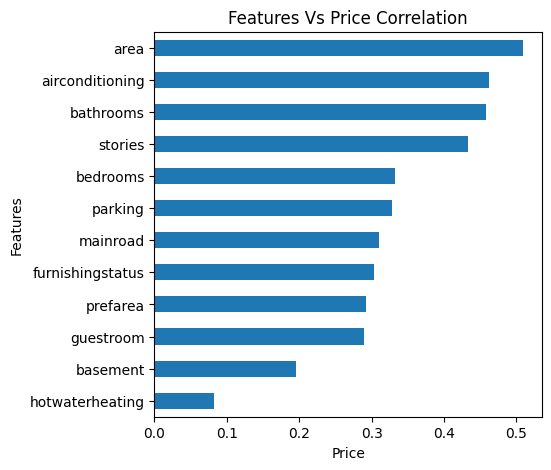

In [14]:
correlation = data.corr()["price"].drop("price")
correlation = correlation.sort_values()
plt.figure(figsize= (5,5))
correlation.plot(kind = "barh")

plt.xlabel("Price")
plt.ylabel("Features")
plt.title("Features Vs Price Correlation")


plt.show()

# Model Training :

In [15]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

Splitting of Data into Test and Training data in ratio of 1:4

In [16]:
x = data.drop(columns="price")
y = data["price"]

x_test, x_train, y_test, y_train = train_test_split(x, y, test_size=0.2, random_state=123)
print(f"The length of test set is : {len(x_test)} \nThe length of training set is : {len(x_train)}")

The length of test set is : 424 
The length of training set is : 106


Training multiple models and finding thier r2 score and choosing the most efficient one, which was RIDGE

In [17]:
# model = LinearRegression()
# model.fit(x_train, y_train)

# y_pred = model.predict(x_test)
# r2 = round(r2_score(y_test, y_pred), 6)

# print(f"The r2 score for Linear Regression is : {r2}")

In [18]:
# poly = PolynomialFeatures(degree = 2)
# x_train = poly.fit_transform(x_train)
# x_test = poly.transform(x_test)

# scaler = StandardScaler()

# x_train = scaler.fit_transform(x_train)
# x_test = scaler.transform(x_test)

# print(f"The number of new features are : {len(x_train[0])}")


In [19]:
model = Ridge(alpha=10)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
r2 = round(r2_score(y_test, y_pred),6)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

print(f"The r2 score is for Ridge is : {r2}")

MAE: 0.7024644373943149
MSE: 0.8943860355708345
The r2 score is for Ridge is : 0.644043


In [20]:
# for i in [1,2,5,7,9, None]:

#     model = DecisionTreeRegressor(max_depth=i, random_state=123)

#     model.fit(x_train, y_train)
#     y_pred = model.predict(x_test)
#     r2 = round(r2_score(y_test, y_pred),6)
#     print(f"The r2 score for Decision Tree with deapth {i} is : {r2}")

In [21]:
# model = RandomForestRegressor(n_estimators=100, random_state=123)

# model.fit(x_train, y_train)
# y_pred = model.predict(x_test)
# r2 = round(r2_score(y_test, y_pred), 6)

# print(f"The r2 score of Random Forest is : {r2}")

In [22]:
# model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=123)

# model.fit(x_train, y_train)
# y_pred = model.predict(x_test)
# r2 = round(r2_score(y_test, y_pred),6)
# print(f"The r2 score of Gradient Boosting is : {r2}")

# Testing with user input to see value

In [23]:
import numpy as np

In [24]:
user_input = np.array([
    [5000, 3, 2, 2, 1, 0, 1, 0, 1, 2, 1, 1]])

predicted_price = model.predict(user_input).round(3)
print(f"The predicted price for these accomodations using Ridge is : {predicted_price} million dollars.")

The predicted price for these accomodations using Ridge is : [6.677] million dollars.


c:\Users\Harsh Deep Yadav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


# Saving the model

In [25]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']